In [ ]:
!pip install koreanize-matplotlib

import koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 18.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import xgboost as xgb
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

train_path = '/content/train.csv'
test_path = '/content/test.csv'

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2452 entries, 0 to 2451
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      2452 non-null   object 
 1   매물확인방식  2452 non-null   object 
 2   보증금     2452 non-null   float64
 3   월세      2452 non-null   int64  
 4   전용면적    1665 non-null   float64
 5   해당층     2223 non-null   float64
 6   총층      2436 non-null   float64
 7   방향      2452 non-null   object 
 8   방수      2436 non-null   float64
 9   욕실수     2434 non-null   float64
 10  주차가능여부  2452 non-null   object 
 11  총주차대수   1756 non-null   float64
 12  관리비     2452 non-null   int64  
 13  중개사무소   2452 non-null   object 
 14  제공플랫폼   2452 non-null   object 
 15  게재일     2452 non-null   object 
 16  허위매물여부  2452 non-null   int64  
dtypes: float64(7), int64(3), object(7)
memory usage: 325.8+ KB


전처리 계획

1. ID: drop
2. 매물확인방식: 레이블 ->
3. 보증금
4. 월세
5. 전용면적
6. 해당층
7. 총층
8. 방향: 레이블 ->
9. 방수
10. 욕실수
11. 주차가능여부: 레이블
12. 총주차대수 -> 없고 있고 차이가 큼 -> 영향을 많이 줄 수도? => 이거 어케 할지
13. 관리비: 그대로
14. 중개사무소: 레이블 -> 유의미
15. 제공플랫폼 -> 없는게 나음
16. 게시일 => 이거 합쳐보기












In [ ]:
train.head()

,ID,매물확인방식,보증금,월세,전용면적,해당층,총층,방향,방수,욕실수,주차가능여부,총주차대수,관리비,중개사무소,제공플랫폼,게재일,허위매물여부
0,TRAIN_0000,현장확인,402500000.0,470000,NaN,NaN,15.0,서향,1.0,1.0,가능,40.0,96,t93Nt6I2I0,B플랫폼,2024-10-09,0
1,TRAIN_0001,현장확인,170500000.0,200000,NaN,3.0,4.0,남동향,2.0,1.0,불가능,NaN,0,q39iV5J4E6,D플랫폼,2024-12-26,0
2,TRAIN_0002,전화확인,114000000.0,380000,NaN,2.0,3.0,동향,1.0,1.0,불가능,NaN,0,b03oE4G3F6,A플랫폼,2024-11-28,0
3,TRAIN_0003,현장확인,163500000.0,30000,36.3,3.0,9.0,남동향,2.0,1.0,가능,13.0,10,G52Iz8V2B9,A플랫폼,2024-11-26,0
4,TRAIN_0004,현장확인,346000000.0,530000,NaN,3.0,3.0,동향,2.0,1.0,불가능,NaN,0,N45gM0M7R0,B플랫폼,2024-06-25,1


열별 결측치 개수

In [ ]:
column_nulls = train.isnull().sum()
print("\n각 열별 null 값 개수:")
column_nulls


각 열별 null 값 개수:


,0
ID,0
매물확인방식,0
보증금,0
월세,0
전용면적,787
해당층,229
총층,16
방향,0
방수,16
욕실수,18


In [ ]:
df_cleaned = train.dropna(subset=['총층', '방수', '욕실수'])

In [ ]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2434 entries, 0 to 2451
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      2434 non-null   object 
 1   매물확인방식  2434 non-null   object 
 2   보증금     2434 non-null   float64
 3   월세      2434 non-null   int64  
 4   전용면적    1664 non-null   float64
 5   해당층     2222 non-null   float64
 6   총층      2434 non-null   float64
 7   방향      2434 non-null   object 
 8   방수      2434 non-null   float64
 9   욕실수     2434 non-null   float64
 10  주차가능여부  2434 non-null   object 
 11  총주차대수   1750 non-null   float64
 12  관리비     2434 non-null   int64  
 13  중개사무소   2434 non-null   object 
 14  제공플랫폼   2434 non-null   object 
 15  게재일     2434 non-null   object 
 16  허위매물여부  2434 non-null   int64  
dtypes: float64(7), int64(3), object(7)
memory usage: 342.3+ KB


In [ ]:
test_cleaned = test.dropna(subset=['총층', '방수', '욕실수'])
test_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 611 entries, 0 to 612
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      611 non-null    object 
 1   매물확인방식  611 non-null    object 
 2   보증금     611 non-null    float64
 3   월세      611 non-null    int64  
 4   전용면적    429 non-null    float64
 5   해당층     563 non-null    float64
 6   총층      611 non-null    float64
 7   방향      611 non-null    object 
 8   방수      611 non-null    float64
 9   욕실수     611 non-null    float64
 10  주차가능여부  611 non-null    object 
 11  총주차대수   437 non-null    float64
 12  관리비     611 non-null    int64  
 13  중개사무소   611 non-null    object 
 14  제공플랫폼   611 non-null    object 
 15  게재일     611 non-null    object 
dtypes: float64(7), int64(2), object(7)
memory usage: 81.1+ KB


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 613 entries, 0 to 612
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      613 non-null    object 
 1   매물확인방식  613 non-null    object 
 2   보증금     613 non-null    float64
 3   월세      613 non-null    int64  
 4   전용면적    429 non-null    float64
 5   해당층     563 non-null    float64
 6   총층      611 non-null    float64
 7   방향      613 non-null    object 
 8   방수      611 non-null    float64
 9   욕실수     611 non-null    float64
 10  주차가능여부  613 non-null    object 
 11  총주차대수   438 non-null    float64
 12  관리비     613 non-null    int64  
 13  중개사무소   613 non-null    object 
 14  제공플랫폼   613 non-null    object 
 15  게재일     613 non-null    object 
dtypes: float64(7), int64(2), object(7)
memory usage: 76.8+ KB


In [ ]:
train.shape

(2452, 17)

In [ ]:
train.head(15)

,ID,매물확인방식,보증금,월세,전용면적,해당층,총층,방향,방수,욕실수,주차가능여부,총주차대수,관리비,중개사무소,제공플랫폼,게재일,허위매물여부
0,TRAIN_0000,현장확인,402500000.0,470000,NaN,NaN,15.0,서향,1.0,1.0,가능,40.0,96,t93Nt6I2I0,B플랫폼,2024-10-09,0
1,TRAIN_0001,현장확인,170500000.0,200000,NaN,3.0,4.0,남동향,2.0,1.0,불가능,NaN,0,q39iV5J4E6,D플랫폼,2024-12-26,0
2,TRAIN_0002,전화확인,114000000.0,380000,NaN,2.0,3.0,동향,1.0,1.0,불가능,NaN,0,b03oE4G3F6,A플랫폼,2024-11-28,0
3,TRAIN_0003,현장확인,163500000.0,30000,36.30,3.0,9.0,남동향,2.0,1.0,가능,13.0,10,G52Iz8V2B9,A플랫폼,2024-11-26,0
4,TRAIN_0004,현장확인,346000000.0,530000,NaN,3.0,3.0,동향,2.0,1.0,불가능,NaN,0,N45gM0M7R0,B플랫폼,2024-06-25,1
5,TRAIN_0005,전화확인,153000000.0,530000,29.50,NaN,3.0,남향,2.0,1.0,가능,1.0,0,Q42YF3Y0I2,A플랫폼,2024-09-12,0
6,TRAIN_0006,현장확인,348500000.0,400000,NaN,2.0,3.0,북동향,1.0,1.0,불가능,NaN,0,A72Mx9C8U2,D플랫폼,2024-08-23,0
7,TRAIN_0007,현장확인,139500000.0,590000,NaN,2.0,3.0,동향,2.0,1.0,불가능,NaN,0,d22DX4Y4P8,B플랫폼,2025-03-03,0
8,TRAIN_0008,현장확인,120500000.0,440000,31.55,1.0,2.0,북향,2.0,2.0,가능,18.0,3,G52Iz8V2B9,B플랫폼,2024-05-23,0
9,TRAIN_0009,현장확인,79500000.0,260000,39.66,2.0,3.0,남동향,2.0,1.0,불가능,2.0,0,M90Ph8W9V3,B플랫폼,2024-11-30,0


In [ ]:
train.head(15)

,ID,매물확인방식,보증금,월세,전용면적,해당층,총층,방향,방수,욕실수,주차가능여부,총주차대수,관리비,중개사무소,제공플랫폼,게재일,허위매물여부
0,TRAIN_0000,현장확인,402500000.0,470000,NaN,NaN,15.0,서향,1.0,1.0,가능,40.0,96,t93Nt6I2I0,B플랫폼,2024-10-09,0
1,TRAIN_0001,현장확인,170500000.0,200000,NaN,3.0,4.0,남동향,2.0,1.0,불가능,NaN,0,q39iV5J4E6,D플랫폼,2024-12-26,0
2,TRAIN_0002,전화확인,114000000.0,380000,NaN,2.0,3.0,동향,1.0,1.0,불가능,NaN,0,b03oE4G3F6,A플랫폼,2024-11-28,0
3,TRAIN_0003,현장확인,163500000.0,30000,36.30,3.0,9.0,남동향,2.0,1.0,가능,13.0,10,G52Iz8V2B9,A플랫폼,2024-11-26,0
4,TRAIN_0004,현장확인,346000000.0,530000,NaN,3.0,3.0,동향,2.0,1.0,불가능,NaN,0,N45gM0M7R0,B플랫폼,2024-06-25,1
5,TRAIN_0005,전화확인,153000000.0,530000,29.50,NaN,3.0,남향,2.0,1.0,가능,1.0,0,Q42YF3Y0I2,A플랫폼,2024-09-12,0
6,TRAIN_0006,현장확인,348500000.0,400000,NaN,2.0,3.0,북동향,1.0,1.0,불가능,NaN,0,A72Mx9C8U2,D플랫폼,2024-08-23,0
7,TRAIN_0007,현장확인,139500000.0,590000,NaN,2.0,3.0,동향,2.0,1.0,불가능,NaN,0,d22DX4Y4P8,B플랫폼,2025-03-03,0
8,TRAIN_0008,현장확인,120500000.0,440000,31.55,1.0,2.0,북향,2.0,2.0,가능,18.0,3,G52Iz8V2B9,B플랫폼,2024-05-23,0
9,TRAIN_0009,현장확인,79500000.0,260000,39.66,2.0,3.0,남동향,2.0,1.0,불가능,2.0,0,M90Ph8W9V3,B플랫폼,2024-11-30,0


허위매물 개수

In [ ]:
#월세가 0원인 건 다 허위 매물임

zero_rent_rows = train[train['월세'] == 0]
zero_rent_rows

,ID,매물확인방식,보증금,월세,전용면적,해당층,총층,방향,방수,욕실수,주차가능여부,총주차대수,관리비,중개사무소,제공플랫폼,게재일,허위매물여부
188,TRAIN_0188,현장확인,5000000.0,0,NaN,4.0,4.0,동향,1.0,1.0,불가능,1.0,9,Z18up3D1C3,A플랫폼,2024-08-27,1
725,TRAIN_0725,서류확인,364000000.0,0,17.50,10.0,16.0,북동향,1.0,1.0,가능,34.0,0,R17wi5N4M8,D플랫폼,2024-05-19,1
809,TRAIN_0809,현장확인,108500000.0,0,18.87,NaN,16.0,동향,1.0,1.0,가능,54.0,0,G38pb6B9C7,C플랫폼,2024-07-16,1
1305,TRAIN_1305,현장확인,18000000.0,0,17.50,NaN,17.0,남동향,1.0,1.0,가능,99.0,0,y86qM5T6T6,A플랫폼,2024-05-16,1


In [ ]:
#관리비가 0원인 건 모름

zero_guan_rows = train[train['관리비'] == 0]
zero_guan_rows

,ID,매물확인방식,보증금,월세,전용면적,해당층,총층,방향,방수,욕실수,주차가능여부,총주차대수,관리비,중개사무소,제공플랫폼,게재일,허위매물여부
1,TRAIN_0001,현장확인,170500000.0,200000,NaN,3.0,4.0,남동향,2.0,1.0,불가능,NaN,0,q39iV5J4E6,D플랫폼,2024-12-26,0
2,TRAIN_0002,전화확인,114000000.0,380000,NaN,2.0,3.0,동향,1.0,1.0,불가능,NaN,0,b03oE4G3F6,A플랫폼,2024-11-28,0
4,TRAIN_0004,현장확인,346000000.0,530000,NaN,3.0,3.0,동향,2.0,1.0,불가능,NaN,0,N45gM0M7R0,B플랫폼,2024-06-25,1
5,TRAIN_0005,전화확인,153000000.0,530000,29.50,NaN,3.0,남향,2.0,1.0,가능,1.0,0,Q42YF3Y0I2,A플랫폼,2024-09-12,0
6,TRAIN_0006,현장확인,348500000.0,400000,NaN,2.0,3.0,북동향,1.0,1.0,불가능,NaN,0,A72Mx9C8U2,D플랫폼,2024-08-23,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2433,TRAIN_2433,현장확인,96500000.0,310000,17.50,3.0,10.0,남동향,2.0,2.0,가능,48.0,0,G52Iz8V2B9,K플랫폼,2025-01-15,0
2437,TRAIN_2437,현장확인,151500000.0,650000,NaN,2.0,3.0,동향,1.0,1.0,불가능,NaN,0,L27JO3N6S2,C플랫폼,2024-12-15,0
2443,TRAIN_2443,현장확인,16500000.0,370000,NaN,4.0,9.0,남향,1.0,1.0,불가능,6.0,0,S06Ox3K4D9,A플랫폼,2024-11-13,0
2444,TRAIN_2444,현장확인,31000000.0,370000,17.50,2.0,7.0,남서향,1.0,1.0,가능,50.0,0,G52Iz8V2B9,A플랫폼,2024-08-27,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

In [ ]:
train[['방수','욕실수']].value_counts()

방수   욕실수
1.0  1.0    1514
2.0  1.0     836
     2.0      84
Name: count, dtype: int64

전처리

In [ ]:
#강현
from sklearn.impute import KNNImputer
from sklearn.ensemble import HistGradientBoostingRegressor

def preprocess_data(df, is_train=True, label_encoders=None):
    df = df.copy()

    # 날짜 데이터 처리 ('게재일' 분리)
    if '게재일' in df.columns:
        df['게재일_년'] = pd.to_datetime(df['게재일']).dt.year
        df['게재일_월'] = pd.to_datetime(df['게재일']).dt.month
        df['게재일_일'] = pd.to_datetime(df['게재일']).dt.day
        df.drop(columns=['게재일'], inplace=True)

    # 열 제거
    cols_to_drop = ['ID', 'index']
    for col in cols_to_drop:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    # 보증금, 월세에 따른 전용면적 결측값 채우기
    df['보증금_월세_가중합'] = df['보증금'] + df['월세'] * 100
    ratio_mean = df.loc[df['전용면적'].notnull(), '전용면적'].mean() / df.loc[df['전용면적'].notnull(), '보증금_월세_가중합'].mean()

    def fill_area(row):
        if np.isnan(row['전용면적']):
            return row['보증금_월세_가중합'] * ratio_mean
        return row['전용면적']

    df['전용면적'] = df.apply(fill_area, axis=1)
    df.drop(columns=['보증금_월세_가중합'], inplace=True)

    # 총층으로 총주차대수 결측값 채우기
    if '총층' in df.columns and '총주차대수' in df.columns:
        knn_imputer = KNNImputer(n_neighbors=3)
        df[['총층', '총주차대수']] = knn_imputer.fit_transform(df[['총층', '총주차대수']])

    # 범주형 데이터 인코딩
    label_cols = ['매물확인방식', '방향', '주차가능여부', '중개사무소', '제공플랫폼']
    if is_train:
        label_encoders = {}
        for col in label_cols:
            if col in df.columns:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                label_encoders[col] = le
    else:
        for col in label_cols:
            if col in df.columns and col in label_encoders:
                le = label_encoders[col]
                # 새로운 값 처리: 보지 못한 값은 -1로 변환
                df[col] = df[col].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

    # 중간값으로 나머지 결측값 처리
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)

    if is_train:
        return df, label_encoders
    else:
        return df


In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

def preprocess_data(df, is_train=True, label_encoders=None):
    df = df.copy()

    # 날짜 데이터 처리 ('게재일' 분리)
    if '게재일' in df.columns:
        df['게재일_년'] = pd.to_datetime(df['게재일']).dt.year
        df['게재일_월'] = pd.to_datetime(df['게재일']).dt.month
        df['게재일_일'] = pd.to_datetime(df['게재일']).dt.day
        df.drop(columns=['게재일'], inplace=True)

    # 열 제거
    cols_to_drop = ['ID', 'index', '제공플랫폼']
    for col in cols_to_drop:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    # 보증금, 월세에 따른 전용면적 결측값 채우기
    df['보증금_월세_가중합'] = df['보증금'] + df['월세'] * 100
    ratio_mean = df.loc[df['전용면적'].notnull(), '전용면적'].mean() / df.loc[df['전용면적'].notnull(), '보증금_월세_가중합'].mean()

    def fill_area(row):
        if np.isnan(row['전용면적']):
            return row['보증금_월세_가중합'] * ratio_mean
        return row['전용면적']

    df['전용면적'] = df.apply(fill_area, axis=1)
    df.drop(columns=['보증금_월세_가중합'], inplace=True)

    # 총층으로 총주차대수 결측값 채우기
    if '총층' in df.columns and '총주차대수' in df.columns:
        knn_imputer = KNNImputer(n_neighbors=3)
        df[['총층', '총주차대수']] = knn_imputer.fit_transform(df[['총층', '총주차대수']])

    # 총층과 총주차대수를 기반으로 해당층 결측값 채우기
    if '해당층' in df.columns:
        knn_imputer_floor = KNNImputer(n_neighbors=3)
        df[['총층', '총주차대수', '해당층']] = knn_imputer_floor.fit_transform(df[['총층', '총주차대수', '해당층']])
        df['해당층'] = df.apply(lambda row: min(row['해당층'], row['총층']), axis=1)

    # 방수 결측값 채우기 (욕실수, 전용면적 기반)
    if '방수' in df.columns and '욕실수' in df.columns and '전용면적' in df.columns:
        knn_imputer_bangsu = KNNImputer(n_neighbors=3)
        df[['방수', '욕실수', '전용면적']] = knn_imputer_bangsu.fit_transform(df[['방수', '욕실수', '전용면적']])

        # 방수 값은 1 또는 2로 제한
        df['방수'] = df['방수'].round().clip(lower=1, upper=2)

    # 범주형 데이터 인코딩
    label_cols = ['매물확인방식', '방향', '주차가능여부', '중개사무소']
    if is_train:
        label_encoders = {}
        for col in label_cols:
            if col in df.columns:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                label_encoders[col] = le
    else:
        for col in label_cols:
            if col in df.columns and col in label_encoders:
                le = label_encoders[col]
                # 새로운 값 처리: 보지 못한 값은 -1로 변환
                df[col] = df[col].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

    # 중간값으로 나머지 결측값 처리
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)

    if is_train:
        return df, label_encoders
    else:
        return df


In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
import pandas as pd
import numpy as np

def preprocess_and_fill_data(df, is_train=True, label_encoders=None, target_columns=None):
    """
    데이터 전처리 및 결측값 채우기 함수.
    :param df: DataFrame
    :param is_train: 학습 데이터 여부 (True일 경우 Label Encoding 학습)
    :param label_encoders: 기존 LabelEncoder 객체들 (Test 데이터 처리 시 사용)
    :param target_columns: 결측값이 있는 칼럼 리스트
    :return: 전처리 및 결측값 채운 DataFrame, Label Encoders
    """
    df = df.copy()

    # 날짜 데이터 처리 ('게재일' 분리)
    if '게재일' in df.columns:
        df['게재일_년'] = pd.to_datetime(df['게재일']).dt.year
        df['게재일_월'] = pd.to_datetime(df['게재일']).dt.month
        df['게재일_일'] = pd.to_datetime(df['게재일']).dt.day
        df.drop(columns=['게재일'], inplace=True)

    # 열 제거
    cols_to_drop = ['ID', 'index']
    for col in cols_to_drop:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    # 범주형 데이터 인코딩
    label_cols = ['매물확인방식', '방향', '주차가능여부', '중개사무소', '제공플랫폼']
    if is_train:
        label_encoders = {}
        for col in label_cols:
            if col in df.columns:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                label_encoders[col] = le
    else:
        for col in label_cols:
            if col in df.columns and col in label_encoders:
                le = label_encoders[col]
                # 새로운 값 처리: 보지 못한 값은 -1로 변환
                df[col] = df[col].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

    # 결측값 채우기 (target_columns 사용)
    if target_columns:
        for target in target_columns:
            # 대상 칼럼의 결측값 위치
            missing_idx = df[target].isna()

            # 결측값이 없으면 스킵
            if not missing_idx.any():
                continue

            # 독립 변수 (결측값 없는 다른 칼럼)
            features = df.drop(columns=target)
            target_data = df[target]

            # 결측값을 제외한 학습 데이터
            train_X = features.loc[~missing_idx]
            train_y = target_data.loc[~missing_idx]

            # 예측할 데이터 (결측값)
            test_X = features.loc[missing_idx]

            # 결측값 채우기 모델
            model = HistGradientBoostingRegressor()
            model.fit(train_X, train_y)

            # 예측값으로 결측치 채우기
            df.loc[missing_idx, target] = model.predict(test_X)

    if is_train:
        return df, label_encoders
    else:
        return df


In [ ]:
# 스케일링 제거
def preprocess_and_fill_data(df, is_train=True, label_encoders=None, target_columns=None):
    """
    기존 함수에서 스케일링 부분 제거
    """
    df = df.copy()

    # 날짜 데이터 처리 ('게재일' 분리)
    if '게재일' in df.columns:
        df['게재일_년'] = pd.to_datetime(df['게재일']).dt.year
        df['게재일_월'] = pd.to_datetime(df['게재일']).dt.month
        df['게재일_일'] = pd.to_datetime(df['게재일']).dt.day
        df.drop(columns=['게재일'], inplace=True)

    # 열 제거
    cols_to_drop = ['ID', 'index']
    for col in cols_to_drop:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    # 범주형 데이터 인코딩
    label_cols = ['매물확인방식', '방향', '주차가능여부', '중개사무소', '제공플랫폼']
    if is_train:
        label_encoders = {}
        for col in label_cols:
            if col in df.columns:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                label_encoders[col] = le
    else:
        for col in label_cols:
            if col in df.columns and col in label_encoders:
                le = label_encoders[col]
                df[col] = df[col].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

    # 결측값 채우기 (target_columns 사용)
    if target_columns:
        for target in target_columns:
            missing_idx = df[target].isna()
            if not missing_idx.any():
                continue

            features = df.drop(columns=target)
            target_data = df[target]

            train_X = features.loc[~missing_idx]
            train_y = target_data.loc[~missing_idx]
            test_X = features.loc[missing_idx]

            model = HistGradientBoostingRegressor(max_iter=100, learning_rate=0.1, max_depth=6, random_state=42)
            model.fit(train_X, train_y)
            df.loc[missing_idx, target] = model.predict(test_X)

    if is_train:
        return df, label_encoders
    else:
        return df

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import HistGradientBoostingRegressor

In [ ]:
# 결측값이 있는 칼럼 정의
missing_columns = ['전용면적', '해당층', '총층', '방수', '욕실수', '총주차대수']

# 학습 데이터 전처리 및 결측값 채우기
train_preprocessed, label_encoders = preprocess_and_fill_data(train, is_train=True, target_columns=missing_columns)
# 테스트 데이터 전처리 및 결측값 채우기
test_preprocessed = preprocess_and_fill_data(test, is_train=False, label_encoders=label_encoders, target_columns=missing_columns)
# Train과 Test의 열 정렬
missing_cols = set(train_preprocessed.columns) - set(test_preprocessed.columns)
for col in missing_cols:
    test_preprocessed[col] = 0

test_preprocessed = test_preprocessed[train_preprocessed.columns.drop('허위매물여부')]

## 현재 catboost에 몰빵중

In [ ]:
!pip install catboost

In [ ]:
def preprocess_for_catboost(df, is_train=True): #현재 1등
    df = df.copy()

    # 날짜 데이터 처리 ('게재일' 분리)
    if '게재일' in df.columns:
        df['게재일_년'] = pd.to_datetime(df['게재일']).dt.year
        df['게재일_월'] = pd.to_datetime(df['게재일']).dt.month
        df['게재일_일'] = pd.to_datetime(df['게재일']).dt.day
        df.drop(columns=['게재일'], inplace=True)

    # 열 제거
    cols_to_drop = ['ID', 'index']
    for col in cols_to_drop:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    # 새로운 특성 추가 (예: 보증금/월세 비율)
    if '보증금' in df.columns and '월세' in df.columns:
        df['보증금_월세_비율'] = df['보증금'] / (df['월세'] + 1)

    # 결측값은 CatBoost가 자동으로 처리하므로 별도 처리 없음
    return df
train_preprocessed = preprocess_for_catboost(train)
test_preprocessed = preprocess_for_catboost(test)
# Train/Validation Split
X = train_preprocessed.drop(columns=['허위매물여부'])
y = train_preprocessed['허위매물여부']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.4, random_state=42)

cat_features = ['매물확인방식', '방향', '주차가능여부', '중개사무소', '제공플랫폼']  # 범주형 칼럼

from catboost import CatBoostClassifier

# 모델 정의
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    cat_features=['매물확인방식', '방향', '주차가능여부', '중개사무소', '제공플랫폼'],  # 범주형 칼럼 지정
    random_state=42,
    verbose=100
)

# 모델 학습
model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)

# 예측 및 평가
y_pred = model.predict(X_val)
f1 = f1_score(y_val, y_pred, average='macro')
print("CatBoost F1 Score:", f1)

# Train과 Test의 열 정렬
missing_cols = set(train_preprocessed.columns) - set(test_preprocessed.columns)
for col in missing_cols:
    test_preprocessed[col] = 0

test_preprocessed = test_preprocessed[train_preprocessed.columns.drop('허위매물여부')]



0:	learn: 0.6525315	test: 0.6526321	best: 0.6526321 (0)	total: 3.37ms	remaining: 1.68s
100:	learn: 0.0680115	test: 0.1188400	best: 0.1188327 (99)	total: 1.05s	remaining: 4.14s
200:	learn: 0.0309448	test: 0.1019929	best: 0.1019712 (198)	total: 2.13s	remaining: 3.17s
300:	learn: 0.0169179	test: 0.0951548	best: 0.0947970 (291)	total: 3.78s	remaining: 2.5s
400:	learn: 0.0108949	test: 0.0930604	best: 0.0927930 (374)	total: 6.02s	remaining: 1.49s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.09279303068
bestIteration = 374

Shrink model to first 375 iterations.
CatBoost F1 Score: 0.9071272308578009


In [ ]:
def preprocess_for_catboost(df, is_train=True):
    df = df.copy()

    # 날짜 데이터 처리 ('게재일' 분리)
    if '게재일' in df.columns:
        df['게재일_년'] = pd.to_datetime(df['게재일']).dt.year
        df['게재일_월'] = pd.to_datetime(df['게재일']).dt.month
        df['게재일_일'] = pd.to_datetime(df['게재일']).dt.day
        df.drop(columns=['게재일'], inplace=True)

    # 열 제거
    cols_to_drop = ['ID', 'index']
    for col in cols_to_drop:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    # 새로운 특성 추가 (예: 보증금/월세 비율)
    if '보증금' in df.columns and '월세' in df.columns:
        df['보증금_월세_비율'] = df['보증금'] / (df['월세'] + 1)

    # 결측값은 CatBoost가 자동으로 처리하므로 별도 처리 없음
    return df
train_preprocessed = preprocess_for_catboost(train)
test_preprocessed = preprocess_for_catboost(test)
# Train/Validation Split
X = train_preprocessed.drop(columns=['허위매물여부'])
y = train_preprocessed['허위매물여부']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.4, random_state=42)

cat_features = ['매물확인방식', '방향', '주차가능여부', '중개사무소', '제공플랫폼']  # 범주형 칼럼

from catboost import CatBoostClassifier

from catboost import CatBoostClassifier


model = CatBoostClassifier(
    iterations=1000,  # 더 많은 반복
    learning_rate=0.03,  # 낮은 학습률
    depth=6,
    l2_leaf_reg=5,  # 규제 파라미터 증가
    class_weights=[1, 2],
    cat_features=cat_features,
    random_state=42,
    early_stopping_rounds=50,  # 조기 종료
    verbose=100
)


# Train 데이터 학습
model.fit(X_train, y_train)

# Validation 데이터 평가
y_val_pred = model.predict(X_val)
f1_val = f1_score(y_val, y_val_pred, average='macro')
print("Validation F1 Score:", f1_val)

# Train과 Test의 열 정렬
missing_cols = set(train_preprocessed.columns) - set(test_preprocessed.columns)
for col in missing_cols:
    test_preprocessed[col] = 0

test_preprocessed = test_preprocessed[train_preprocessed.columns.drop('허위매물여부')]


0:	learn: 0.6688895	total: 4.02ms	remaining: 2.01s
100:	learn: 0.1179087	total: 545ms	remaining: 2.15s
200:	learn: 0.0608187	total: 1.12s	remaining: 1.67s
300:	learn: 0.0367576	total: 1.7s	remaining: 1.13s
400:	learn: 0.0253659	total: 2.26s	remaining: 557ms
499:	learn: 0.0180383	total: 3.38s	remaining: 0us
Validation F1 Score: 0.9153987359706293


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier

def preprocess_for_catboost(df, is_train=True, imputer=None, train_columns=None):
    """
    CatBoost 전용 데이터 전처리 함수 (결측값 처리 + 결측 여부 추가)
    """
    df = df.copy()

    # 날짜 데이터 처리 ('게재일' 분리)
    if '게재일' in df.columns:
        df['게재일_년'] = pd.to_datetime(df['게재일']).dt.year
        df['게재일_월'] = pd.to_datetime(df['게재일']).dt.month
        df['게재일_일'] = pd.to_datetime(df['게재일']).dt.day
        df.drop(columns=['게재일'], inplace=True)

    # 열 제거
    cols_to_drop = ['ID', 'index']
    for col in cols_to_drop:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    # 새로운 특성 추가 (예: 보증금/월세 비율)
    if '보증금' in df.columns and '월세' in df.columns:
        df['보증금_월세_비율'] = df['보증금'] / (df['월세'] + 1)

    # 결측 여부 추가
    for col in ['전용면적', '해당층', '총층', '총주차대수']:
        if col in df.columns:
            df[f'{col}_결측'] = df[col].isna().astype(int)

    # 결측값 채우기 (CatBoost는 결측값을 자동 처리하지만, 채워서 안정성 확보)
    if is_train:
        imputer = SimpleImputer(strategy='median')
        df[['전용면적', '해당층', '총층', '총주차대수']] = imputer.fit_transform(df[['전용면적', '해당층', '총층', '총주차대수']])
    else:
        df[['전용면적', '해당층', '총층', '총주차대수']] = imputer.transform(df[['전용면적', '해당층', '총층', '총주차대수']])

    # Train 데이터와 Test 데이터의 칼럼 구조 맞추기
    if is_train:
        train_columns = df.columns
    else:
        missing_cols = set(train_columns) - set(df.columns)
        for col in missing_cols:
            df[col] = 0  # Train에만 있는 칼럼은 0으로 채움
        df = df[train_columns]  # Train 데이터의 칼럼 순서와 맞춤

    if is_train:
        return df, imputer, train_columns
    else:
        return df

# Train 데이터 전처리
train_preprocessed, imputer, train_columns = preprocess_for_catboost(train, is_train=True)

# Test 데이터 전처리
test_preprocessed = preprocess_for_catboost(test, is_train=False, imputer=imputer, train_columns=train_columns)

# Train/Validation Split
X = train_preprocessed.drop(columns=['허위매물여부'])
y = train_preprocessed['허위매물여부'].astype(int)  # 타겟 변수를 정수형으로 변환
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.4, random_state=42)

# 범주형 칼럼 식별
cat_features = ['매물확인방식', '방향', '주차가능여부', '중개사무소', '제공플랫폼']

# CatBoost 모델 정의
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=10,
    class_weights=[1, 2],  # 클래스 가중치 설정
    cat_features=cat_features,
    random_state=42,
    early_stopping_rounds=50,
    verbose=100
)



# Train 데이터 학습
model.fit(X_train, y_train, eval_set=(X_val, y_val))

# Validation 데이터 평가
y_val_pred = model.predict(X_val)
f1_val = f1_score(y_val, y_val_pred, average='macro')
print("Validation F1 Score:", f1_val)

0:	learn: 0.6691307	test: 0.6701208	best: 0.6701208 (0)	total: 16.9ms	remaining: 16.9s
100:	learn: 0.1721781	test: 0.1871905	best: 0.1871905 (100)	total: 1.23s	remaining: 10.9s
200:	learn: 0.1247225	test: 0.1610874	best: 0.1610874 (200)	total: 2.38s	remaining: 9.44s
300:	learn: 0.0919265	test: 0.1450916	best: 0.1450916 (300)	total: 3.7s	remaining: 8.59s
400:	learn: 0.0710680	test: 0.1364028	best: 0.1363891 (399)	total: 4.31s	remaining: 6.44s
500:	learn: 0.0566866	test: 0.1316203	best: 0.1316203 (500)	total: 4.92s	remaining: 4.9s
600:	learn: 0.0471036	test: 0.1276522	best: 0.1276432 (599)	total: 5.51s	remaining: 3.66s
700:	learn: 0.0394121	test: 0.1256042	best: 0.1255260 (690)	total: 6.6s	remaining: 2.82s
800:	learn: 0.0337854	test: 0.1246086	best: 0.1243623 (765)	total: 7.84s	remaining: 1.95s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.1243622511
bestIteration = 765

Shrink model to first 766 iterations.
Validation F1 Score: 0.9105643780260937


In [ ]:
from sklearn.impute import SimpleImputer################ 0.8407
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier

def preprocess_for_catboost(df, is_train=True, imputer=None, train_columns=None):
    """
    CatBoost 전용 데이터 전처리 함수 (결측값 처리 + 결측 여부 추가)
    """
    df = df.copy()

    # 날짜 데이터 처리 ('게재일' 분리)
    if '게재일' in df.columns:
        df['게재일_년'] = pd.to_datetime(df['게재일']).dt.year
        df['게재일_월'] = pd.to_datetime(df['게재일']).dt.month
        df['게재일_일'] = pd.to_datetime(df['게재일']).dt.day
        df.drop(columns=['게재일'], inplace=True)

    # 열 제거
    cols_to_drop = ['ID', 'index']
    for col in cols_to_drop:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    # 새로운 특성 추가 (예: 보증금/월세 비율)
    if '보증금' in df.columns and '월세' in df.columns:
        df['보증금_월세_비율'] = df['보증금'] / (df['월세'] + 1)

    # 범주형 칼럼을 문자열로 유지
    categorical_cols = ['매물확인방식', '방향', '주차가능여부', '중개사무소', '제공플랫폼']
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype(str)

    # 결측 여부 추가
    for col in ['전용면적', '해당층', '총층', '총주차대수']:
        if col in df.columns:
            df[f'{col}_결측'] = df[col].isna().astype(int)

    # 결측값 채우기
    if is_train:
        imputer = SimpleImputer(strategy='median')
        df[['전용면적', '해당층', '총층', '총주차대수']] = imputer.fit_transform(df[['전용면적', '해당층', '총층', '총주차대수']])
    else:
        df[['전용면적', '해당층', '총층', '총주차대수']] = imputer.transform(df[['전용면적', '해당층', '총층', '총주차대수']])

    # Train 데이터와 Test 데이터의 칼럼 구조 맞추기
    if is_train:
        train_columns = df.columns
    else:
        missing_cols = set(train_columns) - set(df.columns)
        for col in missing_cols:
            df[col] = 0
        df = df[train_columns]

    if is_train:
        return df, imputer, train_columns
    else:
        return df


# Train 데이터 전처리
train_preprocessed, imputer, train_columns = preprocess_for_catboost(train, is_train=True)

# Test 데이터 전처리
test_preprocessed = preprocess_for_catboost(test, is_train=False, imputer=imputer, train_columns=train_columns)

# Train/Validation Split
X = train_preprocessed.drop(columns=['허위매물여부'])
y = train_preprocessed['허위매물여부'].astype(int)

# 범주형 칼럼 인덱스
categorical_cols = ['매물확인방식', '방향', '주차가능여부', '중개사무소', '제공플랫폼']
cat_features_indices = [X.columns.get_loc(col) for col in categorical_cols if col in X.columns]

# CatBoost 모델 정의
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=10,
    class_weights=[1, 2],
    cat_features=cat_features_indices,
    random_state=42,
    early_stopping_rounds=50,
    verbose=100
)

# Cross-Validation으로 일반화 성능 확인
cv_scores = cross_val_score(
    model, X, y, cv=5, scoring='f1_macro'
)

print("Cross-Validation F1 Scores:", cv_scores)
print("Mean Cross-Validation F1 Score:", cv_scores.mean())

# Train/Validation Split (다시 분리)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.4, random_state=42)

# CatBoost 모델 학습
model.fit(X_train, y_train, eval_set=(X_val, y_val))

# Validation 데이터 평가
y_val_pred = model.predict(X_val)
f1_val = f1_score(y_val, y_val_pred, average='macro')
print("Validation F1 Score:", f1_val)

0:	learn: 0.6666727	total: 13.4ms	remaining: 13.3s
100:	learn: 0.1624436	total: 1.71s	remaining: 15.3s
200:	learn: 0.1190931	total: 3s	remaining: 11.9s
300:	learn: 0.0953524	total: 4.48s	remaining: 10.4s
400:	learn: 0.0791146	total: 5.73s	remaining: 8.55s
500:	learn: 0.0663094	total: 6.75s	remaining: 6.72s
600:	learn: 0.0581763	total: 7.37s	remaining: 4.89s
700:	learn: 0.0501383	total: 8.01s	remaining: 3.42s
800:	learn: 0.0416763	total: 8.65s	remaining: 2.15s
900:	learn: 0.0358935	total: 9.27s	remaining: 1.02s
999:	learn: 0.0315569	total: 10.3s	remaining: 0us
0:	learn: 0.6659265	total: 6.41ms	remaining: 6.41s
100:	learn: 0.1561992	total: 1.22s	remaining: 10.9s
200:	learn: 0.1196502	total: 2.57s	remaining: 10.2s
300:	learn: 0.0946937	total: 3.16s	remaining: 7.34s
400:	learn: 0.0783062	total: 3.78s	remaining: 5.64s
500:	learn: 0.0663914	total: 4.42s	remaining: 4.4s
600:	learn: 0.0574445	total: 5.05s	remaining: 3.35s
700:	learn: 0.0491143	total: 5.7s	remaining: 2.43s
800:	learn: 0.0421778

In [ ]:
for col in cat_features:
    train_unique = set(X_train[col].unique())
    test_unique = set(test_preprocessed[col].unique())
    print(f"{col}: Train에만 있는 값 -> {train_unique - test_unique}")
    print(f"{col}: Test에만 있는 값 -> {test_unique - train_unique}")


매물확인방식: Train에만 있는 값 -> set()
매물확인방식: Test에만 있는 값 -> set()
방향: Train에만 있는 값 -> set()
방향: Test에만 있는 값 -> set()
주차가능여부: Train에만 있는 값 -> set()
주차가능여부: Test에만 있는 값 -> set()
중개사무소: Train에만 있는 값 -> {'h59ZP3Z0I9', 'q39iV5J4E6', 'w14tG2G0E3', 'i13Mx4U8C3', 'O63UL1A1D7', 's37cv8A6L4', 'J19lz3U6S5', 'N00fb8Z9A4', 'r14OE6C3A5', 'U47Az5M3I6', 'D49QC8I7L2', 'l96pE8X9A9', 'A21Yr4B1U8', 'x73cN5B8I5', 'q30of0V4I3', 'c25Ms9V8I4', 'b47Pi9K2Q5', 'L57cH2E4P5', 'Y26fH2C0T6', 'u84Ix5E8C2', 'n74bA7B3O7', 'o61te4S1W1', 'l95dK3P5E2', 'E29LO2X8S7', 'b90Kl2S4L3', 'M83sI5S2E5', 'u27qb9S5A1', 'J60uM1S7H0', 'j53Hd6S5I4', 'u92NN7A1E5', 'M20VK3G8C9', 'n49su6P7O6', 'l87eR7Z5E1', 'R12sm8W4R0', 'W63TA3X9H5', 'S78Le0Y9Y4', 'e06Bg9W8S5', 'B91Ts7P1Z7', 'p26Fi7V4A8', 'y70Or6U6A8', 'x63Wv0J5M8', 'E65ar6O9X7', 'n12ez5E0F1', 'i62yA7Y5P1', 'g99sy3I3R8', 'Q65VU2R1S3', 'D23Tf3O2W0', 'o97gJ6P3O8', 'U24ZN1W3V8', 's78XR9X3M2', 'j28Cm6F1K6', 'E29tC1X2E8', 'Y66qe5V3I9', 'P16QI7E8K3', 'j96GJ1G2T3', 'L27JO3N6S2', 'I07Ly5R0J1', 'X75NO1K3

In [ ]:
print("Train 클래스 비율:", y_train.value_counts(normalize=True))
print("Test 클래스 비율:", test_preprocessed.value_counts(normalize=True))


Train 클래스 비율: 허위매물여부
0    0.875595
1    0.124405
Name: proportion, dtype: float64
Test 클래스 비율: 매물확인방식  보증금          월세      전용면적   해당층  총층    방향   방수   욕실수  주차가능여부  총주차대수  관리비  중개사무소       제공플랫폼  게재일_년  게재일_월  게재일_일  보증금_월세_비율  
서류확인    10000000.0   420000  42.61  3.0  8.0   동향   2.0  1.0  가능      13.0   16   l84az9J6A2  A플랫폼   2024   11     16     23.809467      0.003106
현장확인    180000000.0  340000  17.50  3.0  6.0   남동향  1.0  1.0  가능      2.0    8    J52gJ2E4T6  C플랫폼   2024   11     17     529.410208     0.003106
        152500000.0  340000  30.83  4.0  6.0   남동향  1.0  1.0  가능      1.0    2    j90UQ8N6M3  A플랫폼   2024   9      24     448.528093     0.003106
        151500000.0  280000  36.03  4.0  6.0   서향   2.0  1.0  가능      4.0    5    m44pw5A9I1  A플랫폼   2024   10     30     541.069496     0.003106
        150500000.0  400000  29.60  5.0  9.0   남서향  1.0  1.0  가능      8.0    8    W21YE0L9W3  B플랫폼   2024   5      16     376.249059     0.003106
                                         

In [ ]:
# Train 데이터 전처리
train_preprocessed, label_encoders = preprocess_data(train, is_train=True)

# Test 데이터 전처리
test_preprocessed = preprocess_data(test, is_train=False, label_encoders=label_encoders)

# Train과 Test의 열 정렬
missing_cols = set(train_preprocessed.columns) - set(test_preprocessed.columns)
for col in missing_cols:
    test_preprocessed[col] = 0

test_preprocessed = test_preprocessed[train_preprocessed.columns.drop('허위매물여부')]

<ipython-input-26-fad7fa710a2c>:70: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
<ipython-input-26-fad7fa710a2c>:70: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

##K-Fold ensemble + stacking

In [ ]:
import numpy as np #0.84715
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
from xgboost import XGBClassifier

# 1. 전처리 함수
def preprocess_data(df, is_train=True, label_encoders=None):
    """
    데이터 전처리 함수
    """
    df = df.copy()

    # 날짜 데이터 처리 ('게재일' 분리)
    if '게재일' in df.columns:
        df['게재일_년'] = pd.to_datetime(df['게재일']).dt.year
        df['게재일_월'] = pd.to_datetime(df['게재일']).dt.month
        df['게재일_일'] = pd.to_datetime(df['게재일']).dt.day
        df.drop(columns=['게재일'], inplace=True)

    # 열 제거
    cols_to_drop = ['ID', 'index']
    for col in cols_to_drop:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    # 보증금, 월세에 따른 전용면적 결측값 채우기
    df['보증금_월세_가중합'] = df['보증금'] + df['월세'] * 100
    ratio_mean = df.loc[df['전용면적'].notnull(), '전용면적'].mean() / df.loc[df['전용면적'].notnull(), '보증금_월세_가중합'].mean()

    def fill_area(row):
        if np.isnan(row['전용면적']):
            return row['보증금_월세_가중합'] * ratio_mean
        return row['전용면적']

    df['전용면적'] = df.apply(fill_area, axis=1)
    df.drop(columns=['보증금_월세_가중합'], inplace=True)

    # 총층으로 총주차대수 결측값 채우기
    if '총층' in df.columns and '총주차대수' in df.columns:
        knn_imputer = KNNImputer(n_neighbors=3)
        df[['총층', '총주차대수']] = knn_imputer.fit_transform(df[['총층', '총주차대수']])

    # 범주형 데이터 인코딩
    label_cols = ['매물확인방식', '방향', '주차가능여부', '중개사무소', '제공플랫폼']
    if is_train:
        label_encoders = {}
        for col in label_cols:
            if col in df.columns:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                label_encoders[col] = le
    else:
        for col in label_cols:
            if col in df.columns and col in label_encoders:
                le = label_encoders[col]
                # 새로운 값 처리: 보지 못한 값은 -1로 변환
                df[col] = df[col].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

    # 중간값으로 나머지 결측값 처리
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)

    if is_train:
        return df, label_encoders
    else:
        return df

# 2. Train/Test 데이터 전처리
train_preprocessed, label_encoders = preprocess_data(train, is_train=True)
test_preprocessed = preprocess_data(test, is_train=False, label_encoders=label_encoders)

# 3. 데이터 분리
X = train_preprocessed.drop(columns=['허위매물여부'])
y = train_preprocessed['허위매물여부'].astype(int)

<ipython-input-4-54f9c5f5e1b3>:65: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
<ipython-input-4-54f9c5f5e1b3>:65: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [ ]:
import numpy as np #0.84715
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
from xgboost import XGBClassifier

# 1. 전처리 함수
def preprocess_data(df, is_train=True, label_encoders=None):
    """
    데이터 전처리 함수
    """
    df = df.copy()

    # 날짜 데이터 처리 ('게재일' 분리)
    if '게재일' in df.columns:
        df['게재일_년'] = pd.to_datetime(df['게재일']).dt.year
        df['게재일_월'] = pd.to_datetime(df['게재일']).dt.month
        df['게재일_일'] = pd.to_datetime(df['게재일']).dt.day
        df.drop(columns=['게재일'], inplace=True)

    # 열 제거
    cols_to_drop = ['ID', 'index']
    for col in cols_to_drop:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    # 보증금, 월세에 따른 전용면적 결측값 채우기
    df['보증금_월세_가중합'] = df['보증금'] + df['월세'] * 100
    ratio_mean = df.loc[df['전용면적'].notnull(), '전용면적'].mean() / df.loc[df['전용면적'].notnull(), '보증금_월세_가중합'].mean()

    def fill_area(row):
        if np.isnan(row['전용면적']):
            return row['보증금_월세_가중합'] * ratio_mean
        return row['전용면적']

    df['전용면적'] = df.apply(fill_area, axis=1)
    df.drop(columns=['보증금_월세_가중합'], inplace=True)

    # 총층으로 총주차대수 결측값 채우기
    if '총층' in df.columns and '총주차대수' in df.columns:
        knn_imputer = KNNImputer(n_neighbors=3)
        df[['총층', '총주차대수']] = knn_imputer.fit_transform(df[['총층', '총주차대수']])

    # 범주형 데이터 인코딩
    label_cols = ['매물확인방식', '방향', '주차가능여부', '중개사무소', '제공플랫폼']
    if is_train:
        label_encoders = {}
        for col in label_cols:
            if col in df.columns:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                label_encoders[col] = le
    else:
        for col in label_cols:
            if col in df.columns and col in label_encoders:
                le = label_encoders[col]
                # 새로운 값 처리: 보지 못한 값은 -1로 변환
                df[col] = df[col].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

    # 중간값으로 나머지 결측값 처리
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)

    if is_train:
        return df, label_encoders
    else:
        return df

# 2. Train/Test 데이터 전처리
train_preprocessed, label_encoders = preprocess_data(train, is_train=True)
test_preprocessed = preprocess_data(test, is_train=False, label_encoders=label_encoders)

# 3. 데이터 분리
X = train_preprocessed.drop(columns=['허위매물여부'])
y = train_preprocessed['허위매물여부'].astype(int)

# K-Fold Ensemble
kf = KFold(n_splits=5, shuffle=True, random_state=42)
val_preds = []  # Validation 예측값 저장
test_preds = []  # Test 데이터 예측값 저장

for train_idx, val_idx in kf.split(X):
    # Train/Validation Split
    X_train_k, X_val_k = X.iloc[train_idx], X.iloc[val_idx]
    y_train_k, y_val_k = y.iloc[train_idx], y.iloc[val_idx]

    # XGBoost 모델 정의
    model = XGBClassifier(eval_metric='logloss', n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
    model.fit(X_train_k, y_train_k)

    # Validation 데이터 예측 및 저장
    y_val_pred_k = model.predict(X_val_k)
    val_preds.append((val_idx, y_val_pred_k))  # 각 Fold의 Validation 인덱스와 예측값 저장

    # Test 데이터 예측
    test_preds.append(model.predict(test_preprocessed))

# Validation 데이터 전체 예측값 복원
final_val_preds = np.zeros_like(y)  # y와 같은 크기의 배열 생성
for val_idx, y_val_pred_k in val_preds:
    final_val_preds[val_idx] = y_val_pred_k  # Fold별로 예측값을 원래 위치에 복원

# Validation F1 Score 계산
f1_val = f1_score(y, final_val_preds, average='macro')
print("Validation F1 Score (K-Fold Ensemble):", f1_val)

# Test 데이터 예측 앙상블
final_test_preds = np.mean(test_preds, axis=0).round()

# Test 결과 저장 (기존 스타일에 맞게 수정)
output = pd.DataFrame({'ID': test.iloc[:, 0], '허위매물여부': final_test_preds.astype(int)})
output.to_csv('submission23.csv', index=False)
print("submission23.csv 파일이 생성되었습니다.")

<ipython-input-5-d9df353d5b16>:65: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
<ipython-input-5-d9df353d5b16>:65: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

Validation F1 Score (K-Fold Ensemble): 0.901220073664825
submission23.csv 파일이 생성되었습니다.


In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

# Base Model과 Meta Model 정의
base_model_1 = XGBClassifier(eval_metric='logloss', n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
base_model_2 = XGBClassifier(eval_metric='logloss', n_estimators=300, learning_rate=0.03, max_depth=5, random_state=42)
meta_model = LogisticRegression()

# K-Fold 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Validation 예측값 저장
X_meta_train = np.zeros((X.shape[0], 2))  # Base 모델 2개 결과 저장
X_meta_test = np.zeros((test_preprocessed.shape[0], 2, kf.n_splits))  # Test 예측값

# K-Fold Ensemble과 스태킹 학습
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X)):
    # Train/Validation Split
    X_train_k, X_val_k = X.iloc[train_idx], X.iloc[val_idx]
    y_train_k, y_val_k = y.iloc[train_idx], y.iloc[val_idx]

    # Base Model 1
    base_model_1.fit(X_train_k, y_train_k)
    X_meta_train[val_idx, 0] = base_model_1.predict(X_val_k)  # Validation 예측값 저장
    X_meta_test[:, 0, fold_idx] = base_model_1.predict(test_preprocessed)  # Test 예측값 저장

    # Base Model 2
    base_model_2.fit(X_train_k, y_train_k)
    X_meta_train[val_idx, 1] = base_model_2.predict(X_val_k)  # Validation 예측값 저장
    X_meta_test[:, 1, fold_idx] = base_model_2.predict(test_preprocessed)  # Test 예측값 저장

# Test 데이터 앙상블
X_meta_test_mean = np.mean(X_meta_test, axis=2)  # 각 폴드의 Test 예측값 평균

# Meta Model 학습
meta_model.fit(X_meta_train, y)

# Meta Model로 최종 예측
final_test_pred = meta_model.predict(X_meta_test_mean)

# Test 결과 저장
output = pd.DataFrame({'ID': test.iloc[:, 0], '허위매물여부': final_test_pred.astype(int)})
output.to_csv('kfold_stacking_submission.csv', index=False)
print("kfold_stacking_submission.csv 파일이 생성되었습니다.")


kfold_stacking_submission.csv 파일이 생성되었습니다.


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 5.7 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import KFold #0.84715
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import numpy as np
import pandas as pd

# Base Model과 Meta Model 정의
base_model_1 = XGBClassifier(eval_metric='logloss', n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
base_model_2 = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42)
meta_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)

# K-Fold 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Validation 예측값 저장
X_meta_train = np.zeros((X.shape[0], 2))  # Base 모델 2개 결과 저장
X_meta_test = np.zeros((test_preprocessed.shape[0], 2, kf.n_splits))  # Test 예측값

# K-Fold Ensemble과 스태킹 학습
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X)):
    # Train/Validation Split
    X_train_k, X_val_k = X.iloc[train_idx], X.iloc[val_idx]
    y_train_k, y_val_k = y.iloc[train_idx], y.iloc[val_idx]

    # Base Model 1: XGBoost
    base_model_1.fit(X_train_k, y_train_k)
    X_meta_train[val_idx, 0] = base_model_1.predict(X_val_k)  # Validation 예측값 저장
    X_meta_test[:, 0, fold_idx] = base_model_1.predict(test_preprocessed)  # Test 예측값 저장

    # Base Model 2: CatBoost
    base_model_2.fit(X_train_k, y_train_k)
    X_meta_train[val_idx, 1] = base_model_2.predict(X_val_k)  # Validation 예측값 저장
    X_meta_test[:, 1, fold_idx] = base_model_2.predict(test_preprocessed)  # Test 예측값 저장

# Test 데이터 앙상블
X_meta_test_mean = np.mean(X_meta_test, axis=2)  # 각 폴드의 Test 예측값 평균

# Meta Model 학습
meta_model.fit(X_meta_train, y)

# Meta Model로 최종 예측
final_test_pred = meta_model.predict(X_meta_test_mean)

# Test 결과 저장
output = pd.DataFrame({'ID': test.iloc[:, 0], '허위매물여부': final_test_pred.astype(int)})
output.to_csv('kfold_stacking_submission2.csv', index=False)
print("kfold_stacking_submission2.csv 파일이 생성되었습니다.")


kfold_stacking_submission2.csv 파일이 생성되었습니다.


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import numpy as np
import pandas as pd

# Base Model과 Meta Model 정의
base_model_1 = XGBClassifier(eval_metric='logloss', n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
base_model_2 = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42)
meta_model = XGBClassifier(eval_metric='logloss', use_label_encoder=False, n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42)  # XGB로 변경

# K-Fold 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Validation 예측값 저장
X_meta_train = np.zeros((X.shape[0], 2))  # Base 모델 2개 결과 저장
X_meta_test = np.zeros((test_preprocessed.shape[0], 2, kf.n_splits))  # Test 예측값

# K-Fold Ensemble과 스태킹 학습
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X)):
    # Train/Validation Split
    X_train_k, X_val_k = X.iloc[train_idx], X.iloc[val_idx]
    y_train_k, y_val_k = y.iloc[train_idx], y.iloc[val_idx]

    # Base Model 1: XGBoost
    base_model_1.fit(X_train_k, y_train_k)
    X_meta_train[val_idx, 0] = base_model_1.predict(X_val_k)  # Validation 예측값 저장
    X_meta_test[:, 0, fold_idx] = base_model_1.predict(test_preprocessed)  # Test 예측값 저장

    # Base Model 2: CatBoost
    base_model_2.fit(X_train_k, y_train_k)
    X_meta_train[val_idx, 1] = base_model_2.predict(X_val_k)  # Validation 예측값 저장
    X_meta_test[:, 1, fold_idx] = base_model_2.predict(test_preprocessed)  # Test 예측값 저장

# Test 데이터 앙상블
X_meta_test_mean = np.mean(X_meta_test, axis=2)  # 각 폴드의 Test 예측값 평균

# Meta Model 학습
meta_model.fit(X_meta_train, y)

# Meta Model로 최종 예측
final_test_pred = meta_model.predict(X_meta_test_mean)

# Test 결과 저장
output = pd.DataFrame({'ID': test.iloc[:, 0], '허위매물여부': final_test_pred.astype(int)})
output.to_csv('kfold_stacking_submission_xgb.csv', index=False)
print("kfold_stacking_submission_xgb.csv 파일이 생성되었습니다.")


kfold_stacking_submission_xgb.csv 파일이 생성되었습니다.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:20:18] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
from sklearn.model_selection import KFold #0.84715
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
import numpy as np
import pandas as pd

# Base Model과 Meta Model 정의
base_model_1 = XGBClassifier(eval_metric='logloss', n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
base_model_2 = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42)
base_model_3 = LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)  # LGBM 추가
base_model_4 = GradientBoostingClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)  # GBM 추가
meta_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)  # Random Forest as Meta Model


# K-Fold 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Validation 예측값 저장
X_meta_train = np.zeros((X.shape[0], 4))  # Base 모델 4개 결과 저장
X_meta_test = np.zeros((test_preprocessed.shape[0], 4, kf.n_splits))  # Test 예측값

# K-Fold Ensemble과 스태킹 학습
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X)):
    # Train/Validation Split
    X_train_k, X_val_k = X.iloc[train_idx], X.iloc[val_idx]
    y_train_k, y_val_k = y.iloc[train_idx], y.iloc[val_idx]

    # Base Model 1: XGBoost
    base_model_1.fit(X_train_k, y_train_k)
    X_meta_train[val_idx, 0] = base_model_1.predict(X_val_k)
    X_meta_test[:, 0, fold_idx] = base_model_1.predict(test_preprocessed)

    # Base Model 2: CatBoost
    base_model_2.fit(X_train_k, y_train_k)
    X_meta_train[val_idx, 1] = base_model_2.predict(X_val_k)
    X_meta_test[:, 1, fold_idx] = base_model_2.predict(test_preprocessed)

    # Base Model 3: LGBM
    base_model_3.fit(X_train_k, y_train_k)
    X_meta_train[val_idx, 2] = base_model_3.predict(X_val_k)
    X_meta_test[:, 2, fold_idx] = base_model_3.predict(test_preprocessed)

    # Base Model 4: GBM
    base_model_4.fit(X_train_k, y_train_k)
    X_meta_train[val_idx, 3] = base_model_4.predict(X_val_k)
    X_meta_test[:, 3, fold_idx] = base_model_4.predict(test_preprocessed)

# Test 데이터 앙상블
X_meta_test_mean = np.mean(X_meta_test, axis=2)

# Meta Model 학습
meta_model.fit(X_meta_train, y)

# Meta Model로 최종 예측
final_test_pred = meta_model.predict(X_meta_test_mean)

# Test 결과 저장
output = pd.DataFrame({'ID': test.iloc[:, 0], '허위매물여부': final_test_pred.astype(int)})
output.to_csv('kfold_stacking_submission_rf_meta.csv', index=False)
print("kfold_stacking_submission_rf_meta.csv 파일이 생성되었습니다.")

/usr/local/lib/python3.11/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


[LightGBM] [Info] Number of positive: 235, number of negative: 1726
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000324 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1005
[LightGBM] [Info] Number of data points in the train set: 1961, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.119837 -> initscore=-1.993976
[LightGBM] [Info] Start training from score -1.993976
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [ ]:
from sklearn.model_selection import KFold #0.84715
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
import numpy as np
import pandas as pd

# Base Model과 Meta Model 정의
base_model_1 = XGBClassifier(eval_metric='logloss', n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
base_model_2 = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42)
base_model_3 = LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)  # LGBM 추가
base_model_4 = GradientBoostingClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)  # GBM 추가

# Meta Model 정의 (CatBoost)
meta_model = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42)

# K-Fold 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Validation 예측값 저장
X_meta_train = np.zeros((X.shape[0], 4))  # Base 모델 4개 결과 저장
X_meta_test = np.zeros((test_preprocessed.shape[0], 4, kf.n_splits))  # Test 예측값

# K-Fold Ensemble과 스태킹 학습
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X)):
    # Train/Validation Split
    X_train_k, X_val_k = X.iloc[train_idx], X.iloc[val_idx]
    y_train_k, y_val_k = y.iloc[train_idx], y.iloc[val_idx]

    # Base Model 1: XGBoost
    base_model_1.fit(X_train_k, y_train_k)
    X_meta_train[val_idx, 0] = base_model_1.predict(X_val_k)
    X_meta_test[:, 0, fold_idx] = base_model_1.predict(test_preprocessed)

    # Base Model 2: CatBoost
    base_model_2.fit(X_train_k, y_train_k)
    X_meta_train[val_idx, 1] = base_model_2.predict(X_val_k)
    X_meta_test[:, 1, fold_idx] = base_model_2.predict(test_preprocessed)

    # Base Model 3: LGBM
    base_model_3.fit(X_train_k, y_train_k)
    X_meta_train[val_idx, 2] = base_model_3.predict(X_val_k)
    X_meta_test[:, 2, fold_idx] = base_model_3.predict(test_preprocessed)

    # Base Model 4: GBM
    base_model_4.fit(X_train_k, y_train_k)
    X_meta_train[val_idx, 3] = base_model_4.predict(X_val_k)
    X_meta_test[:, 3, fold_idx] = base_model_4.predict(test_preprocessed)

# Test 데이터 앙상블
X_meta_test_mean = np.mean(X_meta_test, axis=2)

# Meta Model 학습
meta_model.fit(X_meta_train, y)

# Meta Model로 최종 예측
final_test_pred = meta_model.predict(X_meta_test_mean)

# Test 결과 저장
output = pd.DataFrame({'ID': test.iloc[:, 0], '허위매물여부': final_test_pred.astype(int)})
output.to_csv('stacking_meta_catboost_submission.csv', index=False)
print("stacking_meta_catboost_submission.csv 파일이 생성되었습니다.")

[LightGBM] [Info] Number of positive: 235, number of negative: 1726
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000279 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1005
[LightGBM] [Info] Number of data points in the train set: 1961, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.119837 -> initscore=-1.993976
[LightGBM] [Info] Start training from score -1.993976
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier
import numpy as np
import pandas as pd

# Base Model과 Meta Model 정의
base_model_1 = XGBClassifier(eval_metric='logloss', n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
base_model_2 = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42)
base_model_3 = LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)  # LGBM 추가
base_model_4 = GradientBoostingClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)  # GBM 추가

# Meta Model 정의 (CatBoost)
meta_model = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42)

# K-Fold 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Validation 예측값 저장
X_meta_train = np.zeros((X.shape[0], 4))  # Base 모델 4개 결과 저장
X_meta_test = np.zeros((test_preprocessed.shape[0], 4, kf.n_splits))  # Test 예측값

# SMOTE 객체 정의
smote = SMOTE(random_state=42)

# K-Fold Ensemble과 스태킹 학습
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X)):
    # Train/Validation Split
    X_train_k, X_val_k = X.iloc[train_idx], X.iloc[val_idx]
    y_train_k, y_val_k = y.iloc[train_idx], y.iloc[val_idx]

    # SMOTE 적용
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_k, y_train_k)

    # Base Model 1: XGBoost
    base_model_1.fit(X_train_resampled, y_train_resampled)
    X_meta_train[val_idx, 0] = base_model_1.predict(X_val_k)
    X_meta_test[:, 0, fold_idx] = base_model_1.predict(test_preprocessed)

    # Base Model 2: CatBoost
    base_model_2.fit(X_train_resampled, y_train_resampled)
    X_meta_train[val_idx, 1] = base_model_2.predict(X_val_k)
    X_meta_test[:, 1, fold_idx] = base_model_2.predict(test_preprocessed)

    # Base Model 3: LGBM
    base_model_3.fit(X_train_resampled, y_train_resampled)
    X_meta_train[val_idx, 2] = base_model_3.predict(X_val_k)
    X_meta_test[:, 2, fold_idx] = base_model_3.predict(test_preprocessed)

    # Base Model 4: GBM
    base_model_4.fit(X_train_resampled, y_train_resampled)
    X_meta_train[val_idx, 3] = base_model_4.predict(X_val_k)
    X_meta_test[:, 3, fold_idx] = base_model_4.predict(test_preprocessed)

# Test 데이터 앙상블
X_meta_test_mean = np.mean(X_meta_test, axis=2)

# Meta Model 학습
meta_model.fit(X_meta_train, y)

# Meta Model로 최종 예측
final_test_pred = meta_model.predict(X_meta_test_mean)

# Test 결과 저장
output = pd.DataFrame({'ID': test.iloc[:, 0], '허위매물여부': final_test_pred.astype(int)})
output.to_csv('stacking_meta_catboost_with_smote_submission.csv', index=False)
print("stacking_meta_catboost_with_smote_submission")


[LightGBM] [Info] Number of positive: 1726, number of negative: 1726
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000383 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2116
[LightGBM] [Info] Number of data points in the train set: 3452, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

In [ ]:
!pip install imbalanced-learn==0.9.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.3/199.3 kB 4.7 MB/s eta 0:00:00
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.13.0
    Uninstalling imbalanced-learn-0.13.0:
      Successfully uninstalled imbalanced-learn-0.13.0


In [ ]:
!pip install --upgrade xgboost lightgbm

In [ ]:
!pip install scikit-learn==1.1.3

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE

# 데이터 전처리
train_preprocessed.fillna(train_preprocessed.median(), inplace=True)
test_preprocessed.fillna(test_preprocessed.median(), inplace=True)

# Train/Validation Split
X = train_preprocessed.drop(columns=['허위매물여부'])
y = train_preprocessed['허위매물여부']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.4, random_state=42)

# SMOTE로 데이터 증강
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# 모델 학습
model = XGBClassifier(
    eval_metric='logloss',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]),  # 클래스 가중치
    random_state=42
)
model.fit(X_train, y_train)

# Validation 데이터 평가
y_pred = model.predict(X_val)
macro_f1 = f1_score(y_val, y_pred, average='macro')
print("\nValidation Macro F1 Score:", macro_f1)

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7e8f6c31fba0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1175, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error



Validation Macro F1 Score: 0.8484185753509325


In [ ]:
train.head(5)

,ID,매물확인방식,보증금,월세,전용면적,해당층,총층,방향,방수,욕실수,주차가능여부,총주차대수,관리비,중개사무소,제공플랫폼,게재일,허위매물여부,보증금_월세_비율,면적_층수_비율
0,TRAIN_0000,현장확인,402500000.0,470000,NaN,NaN,15.0,서향,1.0,1.0,가능,40.0,96,t93Nt6I2I0,B플랫폼,2024-10-09,0,856.381157,NaN
1,TRAIN_0001,현장확인,170500000.0,200000,NaN,3.0,4.0,남동향,2.0,1.0,불가능,NaN,0,q39iV5J4E6,D플랫폼,2024-12-26,0,852.495738,NaN
2,TRAIN_0002,전화확인,114000000.0,380000,NaN,2.0,3.0,동향,1.0,1.0,불가능,NaN,0,b03oE4G3F6,A플랫폼,2024-11-28,0,299.999211,NaN
3,TRAIN_0003,현장확인,163500000.0,30000,36.3,3.0,9.0,남동향,2.0,1.0,가능,13.0,10,G52Iz8V2B9,A플랫폼,2024-11-26,0,5449.818339,3.63
4,TRAIN_0004,현장확인,346000000.0,530000,NaN,3.0,3.0,동향,2.0,1.0,불가능,NaN,0,N45gM0M7R0,B플랫폼,2024-06-25,1,652.828957,NaN


In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

X = train_preprocessed.drop(columns=['허위매물여부'])
y = train_preprocessed['허위매물여부']

# test_size 0.2, 0,3, 0.4, 0.5 중 0.4가 제일 나음 0.4로 했을 때 많이 오름
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.4, random_state=42)

model = XGBClassifier(eval_metric='logloss')#,n_estimators=500, learning_rate=0.05, random_state=156
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

macro_f1 = f1_score(y_val, y_pred, average='macro')
print("\nMacro F1 Score:", macro_f1)


Macro F1 Score: 0.8879127575569069


In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# 데이터 분할
X = train_preprocessed.drop(columns=['허위매물여부'])
y = train_preprocessed['허위매물여부']

# Train/Validation Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.4, random_state=42)

# XGBoost 모델 정의 (파라미터 수정 가능)
model = XGBClassifier(
    eval_metric='logloss',     # 평가 지표
    n_estimators=500,          # 트리 개수
    learning_rate=0.1,        # 학습률
    max_depth=8,               # 트리의 최대 깊이
    colsample_bytree=1,      # 각 트리의 특성 샘플링 비율
    subsample=1,             # 데이터 샘플링 비율
    random_state=42            # 재현성을 위한 랜덤 시드
)

# 모델 학습
model.fit(X_train, y_train)

# Validation 데이터 예측
y_pred = model.predict(X_val)

# F1 Score 평가
macro_f1 = f1_score(y_val, y_pred, average='macro')
print("\nMacro F1 Score:", macro_f1)


Macro F1 Score: 0.8920667818077144


In [ ]:
# 테스트 데이터 예측
test_predictions = model.predict(test_preprocessed)

# 결과 저장
output = pd.DataFrame({'ID': test.iloc[:, 0], '허위매물여부': test_predictions})
output.to_csv('submission22.csv', index=False)
print("submission4.csv 파일이 생성되었습니다.")

submission4.csv 파일이 생성되었습니다.


In [ ]:
!pip install --upgrade xgboost scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 14.8 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.0
    Uninstalling scikit-learn-1.6.0:
      Successfully uninstalled scikit-learn-1.6.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

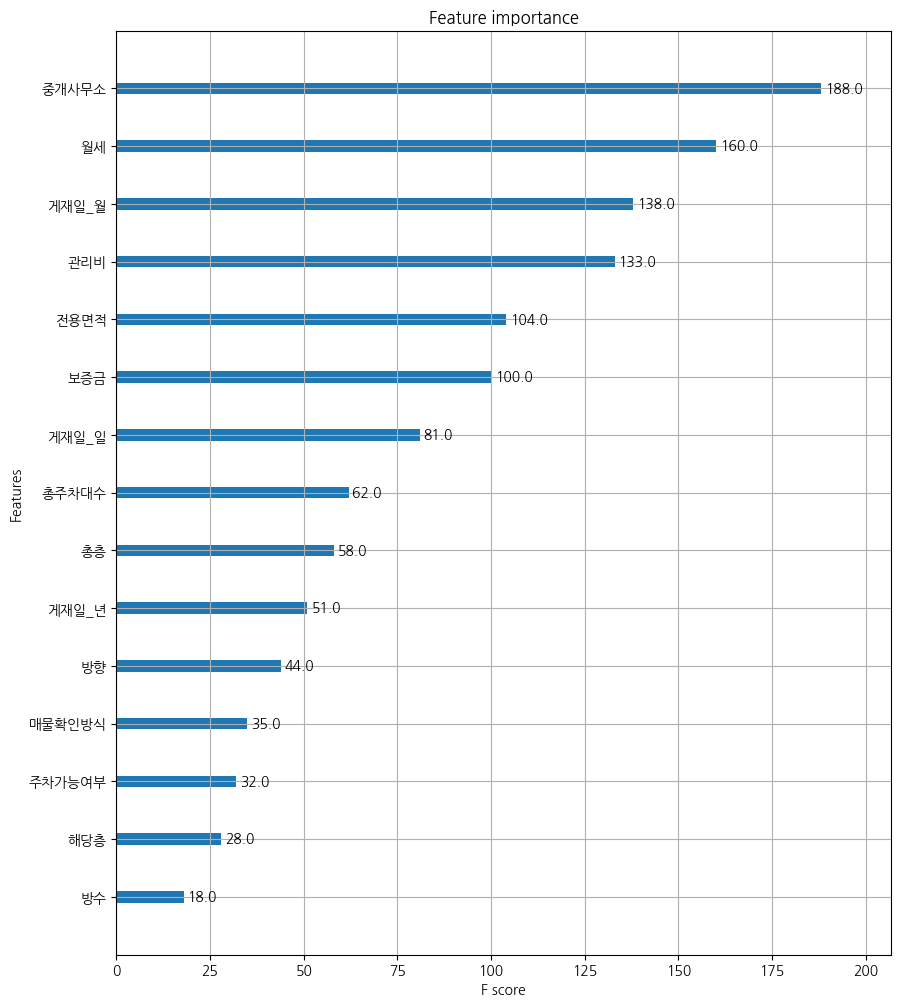

In [ ]:
fig, ax = plt.subplots(figsize=(10, 12))
xgb.plot_importance(model, ax=ax)

In [ ]:
# # train 데이터에서 X_train, Y_train 생성
# X_train = train_preprocessed.drop(columns=['허위매물여부'])
# y_train = train_preprocessed['허위매물여부']

# # 데이터 확인
# print("X_train shape:", X_train.shape)
# print("y_train shape:", y_train.shape)

In [ ]:
# from sklearn.model_selection import train_test_split

# X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=0)

In [ ]:
# from xgboost import XGBClassifier
# from sklearn.metrics import roc_auc_score

# xgb_clf = XGBClassifier(n_estimators=500, learning_rate=0.05, random_state=156)

# xgb_clf.fit(X_tr, Y_tr, early_stopping_rounds=50, eval_metric='auc', eval_set=[(X_tr, Y_tr), (X_val, Y_val)])

# xgb_roc_score = roc_auc_score(Y_test, xgb_clf.predict_proba(X_test)[:, 1])
# print('ROC AUC: {0:.4f}'.format(xgb_roc_score))